# VIX Settlement Day — the stats teardown 🎯

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Faded after 2018?: Mixed](https://img.shields.io/badge/Faded_after_2018%3F-Mixed-8b949e?style=flat-square)

**Claim under test** (Griffin & Shams 2018, RFS): the monthly VIX-derivative settlement auction systematically deviates. **Our question:** does the settlement Wednesday leave tracks in the daily ^VIX bar (2004-2026)?

Sample: **270** rule-built settlements (verified against 18 CBOE dates) vs **899** other Wednesdays; as-of **2026-06-30**; fingerprints `2f08bb9304e8` / `731fc130d08d`. Welch *t* for group splits, White (HC1) *t* for regressions (single-day non-overlapping events). Canonical numbers: [docs/results.md](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vix_settlement_day import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    VIX, SPX = data.load_real()
    SETT = data.settlement_calendar()
    DF = st.day_frame(VIX, SPX, settlements=SETT)
else:
    VIX = SPX = SETT = DF = None
print("real cache present:", HAVE_REAL,
      "| settlements:", (0 if SETT is None else len(SETT)),
      "| days:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2004-01-02', 'end': '2026-06-30', 'asof': '2026-06-30', 'n_sett': 270, 'n_wed': 899, 'n_overlap': 40, 'n_known': 18, 'tuesdays': ['2008-02-19', '2014-03-18', '2019-03-19', '2022-03-15', '2024-06-18', '2025-03-18', '2026-05-19'], 'levels': [('open gap ln(O/C-1), mean', 0.043, 0.016, 0.11, None), ('|open gap|', 2.41, 2.185, 1.3, 0.9), ('intraday ln(C/O), mean', -0.238, -0.762, 1.06, None), ('|intraday|', 5.0, 4.468, 1.48, None), ('|close-close|', 5.861, 4.88, 2.42, 1.73), ('range (H-L)/C-1', 10.088, 9.078, 2.17, 0.98), ('SPX close-close, mean', -0.079, 0.09, -2.06, -1.77)], 'n_sett_exfomc': 230, 'n_wed_exfomc': 797, 'inter_all': (-0.179, -2.3, 0.249, 0.427, 2.56, 1169), 'inter_ex': (-0.195, -2.42, 0.302, 0.497, 2.86, 1027), 'placebo': {'obs': 0.497, 'mean': -0.023, 'sd': 0.172, 'p': 0.0025, 'draws': 2000, 'seeds': 25}, 'robust': [('drop exact-zero gaps (stale-open artefact)', 0.496, 2.86, 986), ('winsorise gap/intr at 1%/99%', 0.447, 2.81, 1027)], 'fade_inter': {'pre': (0.468, 2.31, 148), 'post': (0.49, 1.53, 82)}, 'fade_level': {'all_pre': 3.1, 'all_post': 0.18, 'ex_pre': 2.21, 'ex_post': -0.2}, 'split': '2018-01-01', 'trade': {'gross': -0.024, 't0': -0.05, 't_vs': 0.67, 'n': 262, 'other': -0.361, 'net': -0.524, 'net_yr': -6.29, 'cost_bps': 25.0}, 'syn': [(0.0, 0.025, 0.25), (0.5, 0.525, 5.22)], 'fp_vix': '2f08bb9304e8', 'fp_spx': '731fc130d08d'}


real cache present: True | settlements: 270 | days: 5658


## 1 · Calendar construction + verification

Final settlement = the Wednesday 30 days before the *following* month's SPX expiry (third Friday, holiday-stepped), itself holiday-stepped — Good Friday via the Gregorian Easter algorithm, Juneteenth from 2022. Asserted against 18 known CBOE dates including all 7 holiday-shifted Tuesdays.

> 💡 **In plain words** — the settlement date is pure arithmetic known years in advance, so there is no look-ahead anywhere in this study: the *only* same-day input is the open print itself.

In [2]:
print('verified against', data.verify_calendar(), 'known CBOE dates')
cal = data.settlement_calendar()
print(len(cal), 'settlements', cal.min().date(), '->', cal.max().date())
print('Tuesdays:', [str(d.date()) for d in cal[cal.weekday == 1]])
if HAVE_REAL:
    from quantlab.repro import data_stamp
    print(data_stamp('^VIX OHLC', VIX, asof=data.AS_OF))
    print(data_stamp('^GSPC OHLC', SPX, asof=data.AS_OF))

verified against 18 known CBOE dates
270 settlements 2004-01-21 -> 2026-06-17
Tuesdays: ['2008-02-19', '2014-03-18', '2019-03-19', '2022-03-15', '2024-06-18', '2025-03-18', '2026-05-19']
[data] ^VIX OHLC: 5,659 rows  2004-01-02 -> 2026-06-30  as-of 2026-06-30  fingerprint=2f08bb9304e8
[data] ^GSPC OHLC: 5,658 rows  2004-01-02 -> 2026-06-30  as-of 2026-06-30  fingerprint=731fc130d08d


## 2 · Level tests — and the FOMC confounder

The planned Welch splits (settlement days vs other Wednesdays), run twice: on all days, and with **FOMC statement days removed** — 40 of the 270 settlements coincide with FOMC Wednesdays (source: the Fed calendar table shared with studies 67/135/517).

> 💡 **In plain words** — mid-month Wednesday is *also* where the Fed lives. Any settlement study that skips this control is measuring monetary policy.

In [3]:
if HAVE_REAL:
    for tag, ex in (('ALL', False), ('ex-FOMC', True)):
        lv = st.level_tests(DF, ex_fomc=ex)
        print(f"--- {tag}: n={lv['n_sett']} vs {lv['n_other']}")
        for k in ('gap','abs_gap','intr','abs_intr','cc','abs_cc','rng','spx'):
            v = lv[k]
            print(f"  {k:8s} sett {v['sett']*100:+7.3f}%  other {v['other']*100:+7.3f}%  "
                  f"Welch t={v['t']:+.2f}")
else:
    for row in R['levels']: print(row)

--- ALL: n=270 vs 899
  gap      sett  +0.043%  other  +0.016%  Welch t=+0.11
  abs_gap  sett  +2.410%  other  +2.185%  Welch t=+1.30
  intr     sett  -0.238%  other  -0.762%  Welch t=+1.06
  abs_intr sett  +5.000%  other  +4.468%  Welch t=+1.48
  cc       sett  -0.196%  other  -0.746%  Welch t=+0.98
  abs_cc   sett  +5.861%  other  +4.880%  Welch t=+2.42
  rng      sett +10.088%  other  +9.078%  Welch t=+2.17
  spx      sett  -0.079%  other  +0.090%  Welch t=-2.06
--- ex-FOMC: n=230 vs 797
  gap      sett  +0.320%  other  +0.069%  Welch t=+0.97
  abs_gap  sett  +2.414%  other  +2.245%  Welch t=+0.90
  intr     sett  -0.185%  other  -0.764%  Welch t=+1.24
  abs_intr sett  +4.624%  other  +4.407%  Welch t=+0.68
  cc       sett  +0.134%  other  -0.695%  Welch t=+1.49
  abs_cc   sett  +5.492%  other  +4.819%  Welch t=+1.73
  rng      sett  +9.332%  other  +8.948%  Welch t=+0.98
  spx      sett  -0.073%  other  +0.079%  Welch t=-1.77


**Read-out.** All-days, two level stats clear the bar — |close-close| (*t* = +2.42) and range (*t* = +2.17) — and SPX prints red (*t* = −2.06). Ex-FOMC (n = 230 vs 797) **all of them fall under 2**: |gap| +0.90, |close-close| +1.73, range +0.98, SPX −1.77. The level story does not survive the confounder. *(No level claim is stamped Real.)*

## 3 · The signature — settlement × gap continuation

`intr = a + b·gap + c·sett + d·(gap × sett)` on settlement days + other Wednesdays, White (HC1) robust *t*. `b` is the normal-Wednesday gap fade; `d` is the settlement distortion of that fade.

> 💡 **In plain words** — we're not asking whether settlement days move more; we're asking whether the *morning move behaves differently*: normally the VIX takes back its opening gap during the day; on settlement day it keeps it. That's what a pushed opening auction should look like from daily bars.

In [4]:
if HAVE_REAL:
    for tag, ex in (('ALL days', False), ('ex-FOMC ', True)):
        r = st.interaction(DF, ex_fomc=ex)
        print(f"{tag}: b={r['base_slope']:+.3f} (t={r['base_t']:+.2f})  "
              f"b+d={r['sett_slope']:+.3f}  d={r['inter']:+.3f} (t={r['inter_t']:+.2f})  "
              f"n={r['n']}")
else:
    print('all  :', R['inter_all']); print('exfomc:', R['inter_ex'])

ALL days: b=-0.179 (t=-2.30)  b+d=+0.249  d=+0.427 (t=+2.56)  n=1169
ex-FOMC : b=-0.195 (t=-2.42)  b+d=+0.302  d=+0.497 (t=+2.86)  n=1027


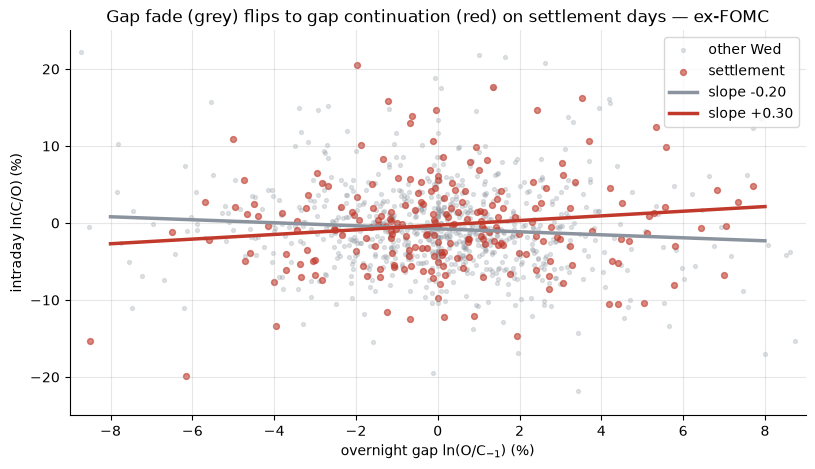

In [5]:
if HAVE_REAL:
    d = st.event_sample(DF, ex_fomc=True)
    s, o = d[d['sett']], d[~d['sett']]
    fig, ax = plt.subplots()
    ax.scatter(o['gap']*100, o['intr']*100, s=8, alpha=.25, color=GREY, label='other Wed')
    ax.scatter(s['gap']*100, s['intr']*100, s=18, alpha=.6, color=RED, label='settlement')
    for g, c in ((o, GREY), (s, RED)):
        b = np.polyfit(g['gap'], g['intr'], 1)
        xs = np.linspace(-8, 8, 20)
        ax.plot(xs, (b[0]*xs/100 + b[1])*100, color=c, lw=2.5, label=f'slope {b[0]:+.2f}')
    ax.set_xlim(-9, 9); ax.set_ylim(-25, 25)
    ax.set_xlabel('overnight gap ln(O/C$_{-1}$) (%)'); ax.set_ylabel('intraday ln(C/O) (%)')
    ax.set_title('Gap fade (grey) flips to gap continuation (red) on settlement days — ex-FOMC')
    ax.legend(); plt.show()

## 4 · Random-calendar placebo (≥ 20 seeds)

One fake settlement Wednesday per month drawn among non-settlement Wednesdays (ex-FOMC), same interaction regression. Canonical run: **2,000 draws over 25 seeds** → two-sided **p = 0.0025** (observed +0.497 vs placebo -0.023 ± 0.172). The cell below re-runs a REDUCED version (200 draws / 5 seeds) to keep the notebook light.

In [6]:
if HAVE_REAL:
    pl = st.placebo_interaction(DF, ex_fomc=True, n_seeds=5, n_per=40)
    print(f"reduced placebo: obs {pl['obs']:+.3f} vs {pl['mean']:+.3f} (sd {pl['sd']:.3f}) "
          f"over {pl['n_draws']} draws -> p={pl['p_two_sided']:.4f}")
print('canonical (2,000 draws / 25 seeds): p =', R['placebo']['p'])

reduced placebo: obs +0.497 vs -0.031 (sd 0.169) over 200 draws -> p=0.0000
canonical (2,000 draws / 25 seeds): p = 0.0025


## 5 · Robustness — data quirks and tails

Yahoo's ^VIX open exactly equals the prior close on ~4% of days (~30% in 2008-09) — a stale-open artefact that only *dilutes* the gap variable. And fat-tailed days could own an OLS slope. Neither carries the result:

In [7]:
if HAVE_REAL:
    r1 = st.interaction(DF, ex_fomc=True, drop_zero_gaps=True)
    r2 = st.interaction(DF, ex_fomc=True, winsor=0.01)
    print(f"drop zero gaps : d={r1['inter']:+.3f} (t={r1['inter_t']:+.2f}, n={r1['n']})")
    print(f"winsor 1%/99%  : d={r2['inter']:+.3f} (t={r2['inter_t']:+.2f}, n={r2['n']})")
else:
    for row in R['robust']: print(row)

drop zero gaps : d=+0.496 (t=+2.86, n=986)
winsor 1%/99%  : d=+0.447 (t=+2.81, n=1027)


## 6 · Third axis — the 2018 fade test

Split at **2018-01-01** (RFS publication + the consolidated antitrust litigation + CBOE auction tweaks — a justified, not snooped, split).

> 💡 **In plain words** — if the print was being pushed and the pushing stopped when the lawyers arrived, the fingerprint should disappear after 2018. The *noise* part did; the *continuation* part didn't.

In [8]:
if HAVE_REAL:
    sp = st.subperiod_interactions(DF, ex_fomc=True)
    for lbl, r in (('2004-2017', sp['pre']), ('2018-2026', sp['post'])):
        print(f"{lbl}: d={r['inter']:+.3f} (t={r['inter_t']:+.2f}, n_sett={r['n_sett']})")
    sl = st.subperiod_levels(DF)
    for tag in ('all', 'ex_fomc'):
        print(f"|cc| level t ({tag}): {sl[tag]['pre']['t']:+.2f} -> {sl[tag]['post']['t']:+.2f}")
else:
    print(R['fade_inter']); print(R['fade_level'])

2004-2017: d=+0.468 (t=+2.31, n_sett=148)
2018-2026: d=+0.490 (t=+1.53, n_sett=82)
|cc| level t (all): +3.10 -> +0.18
|cc| level t (ex_fomc): +2.21 -> -0.20


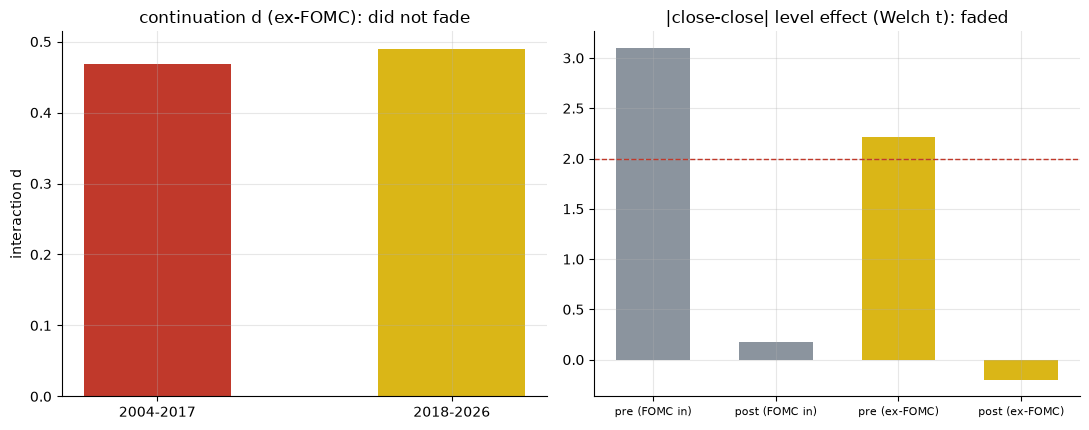

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
pre, post = R['fade_inter']['pre'], R['fade_inter']['post']
axes[0].bar(['2004-2017', '2018-2026'], [pre[0], post[0]], color=[RED, AMBER], width=.5)
axes[0].set_title('continuation d (ex-FOMC): did not fade')
axes[0].set_ylabel('interaction d')
fl = R['fade_level']
axes[1].bar(['pre (FOMC in)', 'post (FOMC in)', 'pre (ex-FOMC)', 'post (ex-FOMC)'],
            [fl['all_pre'], fl['all_post'], fl['ex_pre'], fl['ex_post']],
            color=[GREY, GREY, AMBER, AMBER], width=.6)
axes[1].axhline(2, color=RED, lw=1, ls='--')
axes[1].set_title('|close-close| level effect (Welch t): faded')
axes[1].tick_params(axis='x', labelsize=8)
plt.tight_layout(); plt.show()

## 7 · Tradability — the honest cash-out attempt

Rule: at the settlement-day open (calendar known years ahead; the open print is the only same-day input — **one clean lag**), position = sign(gap), exit at the close. Index log units — **the index is not tradable**; costs at VIX-futures retail level (25 bps one-way × 2), and even this flatters the trade (the futures under-react to spot; the expiring contract has already printed its SOQ).

In [10]:
if HAVE_REAL:
    tp = st.continuation_pnl(DF, ex_fomc=False, cost_bps_oneway=25.0)
    print(f"gross {tp['gross_per_event']*100:+.3f}%/event (t vs 0 = {tp['t_vs_zero']:+.2f}, "
          f"t vs other Wed = {tp['t_vs_otherwed']:+.2f}, n={tp['n']})")
    print(f"other Wednesdays {tp['other_wed']*100:+.3f}%/event")
    print(f"net {tp['net_per_event']*100:+.3f}%/event x 12/yr = {tp['net_per_year']*100:+.2f}%/yr")
else:
    print(R['trade'])

gross -0.024%/event (t vs 0 = -0.05, t vs other Wed = +0.67, n=262)
other Wednesdays -0.361%/event
net -0.524%/event x 12/yr = -6.29%/yr


> 💡 **In plain words** — the fingerprint is a *covariance* (big gaps carry through in proportion), not a directional edge you can harvest with a sign rule 12 times a year. Gross ≈ 0, net deeply negative. **Mirage.**

## 8 · Synthetic control — machinery proof (never market evidence)

A deterministic 44-year world where normal-day gaps fade (slope −0.20) and settlement days carry a **planted** extra gap→close slope. The pipeline must stay quiet at 0 and light up at +0.50:

In [11]:
for planted in (0.0, 0.5):
    world = data.synthetic_world(planted=planted, seed=605)
    sdf = st.day_frame(world, spx=None)
    r = st.interaction(sdf, ex_fomc=False)
    print(f"planted {planted:+.2f}: recovered d={r['inter']:+.3f} (t={r['inter_t']:+.2f}, "
          f"n_sett={r['n_sett']})")

planted +0.00: recovered d=+0.025 (t=+0.25, n_sett=528)


planted +0.50: recovered d=+0.525 (t=+5.22, n_sett=528)


## Verdict

- **Signal — MIXED.** Real on the structure: settlement × gap continuation d = +0.427 (White t = +2.56) all days, +0.497 (t = +2.86) ex-FOMC, placebo p = 0.0025, robust to the stale-open screen and winsorising. None on the level: every planned Welch split dies ex-FOMC (all |t| < 2).
- **Tradability — MIRAGE.** Untradable index; sign rule -0.024%/event gross (t ≈ 0), -6.3%/yr net.
- **Faded after 2018? — MIXED.** Level effect gone (+3.10 → +0.18); continuation unchanged in point estimate (+0.468 → +0.490) but under-powered post-2018 (t = +1.53, n = 82).

*Canonical numbers: [docs/results.md](../docs/results.md) · plain-words tour: [01_for_the_curious.ipynb](01_for_the_curious.ipynb)*